In [1]:
from afm_lib.instrument.session import call
from afm_lib.utils.recipe_builder import (
    line_sites, grid_sites, check_sites, preview_sites, write_recipe)

In [2]:
raw = await call("pfm_get_experiment_status")
P0 = (raw["stage_x_m"], raw["stage_y_m"])
print(f"P0 = ({P0[0]*1e3:+.4f}, {P0[1]*1e3:+.4f}) mm")

P0 = (+21.0640, +20.8130) mm


In [3]:
raw = await call("pfm_get_experiment_status")
P1 = (raw["stage_x_m"], raw["stage_y_m"])
span = ((P1[0]-P0[0])**2 + (P1[1]-P0[1])**2) ** 0.5
print(f"P1 = ({P1[0]*1e3:+.4f}, {P1[1]*1e3:+.4f}) mm")
print(f"span = {span*1e3:.3f} mm")

P1 = (-18.9800, +21.3910) mm
span = 40.048 mm


11 sites, spacing 4.005 mm
  ! closest pair: 4005 um (must exceed STAGE_TOL_M or ensure_stage will skip the move)


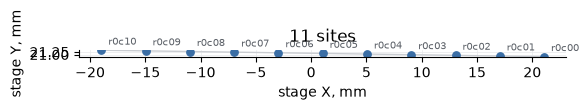

In [15]:
N_SITES = 11

line  = line_sites(P0, P1, N_SITES)
sites = grid_sites(line)                      # single row
print(f"{len(sites)} sites, spacing {span/(N_SITES-1)*1e3:.3f} mm")
for p in check_sites(sites):
    print("  !", p)
preview_sites(sites)

88 sites (8 rows x 11)
  ! closest pair: 4000 um (must exceed STAGE_TOL_M or ensure_stage will skip the move)


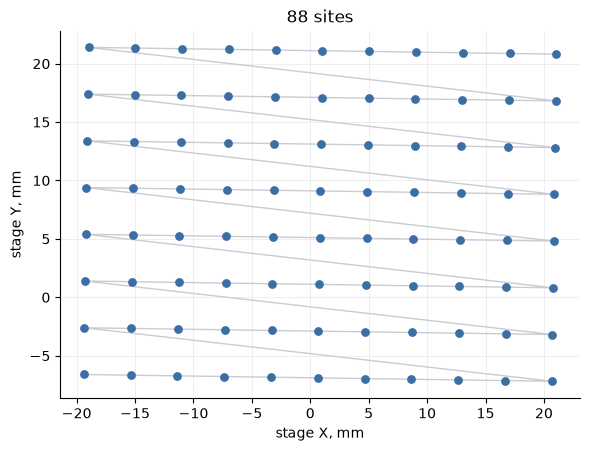

In [16]:
N_ROWS  = 8
ROW_SPACING_M = 4.0e-3          # perpendicular to the P0->P1 line

sites = grid_sites(line, N_ROWS, ROW_SPACING_M)
print(f"{len(sites)} sites ({N_ROWS} rows x {N_SITES})")
for p in check_sites(sites):
    print("  !", p)
preview_sites(sites)

In [18]:
LOOP_SETTINGS = dict(v_dc_max_v=20.0, frequency_hz=0.3, var0_phase=0.0,
                     var1_pulsetime_s=0.05, n_cycles=3)
POINTS_M = [(-1.0e-6, -1.0e-6), (1.0e-6, -1.0e-6),
            (-1.0e-6,  1.0e-6), (1.0e-6,  1.0e-6),
            (0., 2.0e-6), (0., -2.0e-6),
            (-2.0e-6, 0.), (2.0e-6, 0.)]

p = write_recipe("../recipes/alscn_01448_grid.yaml",
                 name="alscn_01448",
                 sites=sites,
                 loop_settings=LOOP_SETTINGS,
                 points_m=POINTS_M,
                 context="AlScN PDAC_COM5_01448 combinatorial library. "
                         "starting point is 100 um below left bottom electrode")
print("wrote", p)
print(p.read_text(encoding="utf-8")[:600])

wrote ..\recipes\alscn_01448_grid.yaml
name: alscn_01448
context: AlScN PDAC_COM5_01448 combinatorial library. starting point is 100 um below
  left bottom electrode
sites:
- label: r0c00
  x_stage_m: 0.021064
  y_stage_m: 0.020812999
- label: r0c01
  x_stage_m: 0.0170596
  y_stage_m: 0.020870799199999998
- label: r0c02
  x_stage_m: 0.0130552
  y_stage_m: 0.020928599399999998
- label: r0c03
  x_stage_m: 0.0090508
  y_stage_m: 0.0209863996
- label: r0c04
  x_stage_m: 0.0050463999999999995
  y_stage_m: 0.0210441998
- label: r0c05
  x_stage_m: 0.0010420000000000013
  y_stage_m: 0.021102
- label: r0c06
  x_stage_m: -0.00296240000000000


In [19]:
from afm_lib.schemas.recipe import load_recipe, site_program

r = load_recipe(p)
n_meas = len(r.sites) * len(site_program(r))
ls = r.per_site[0].loop_settings
per_loop = ls.n_cycles / ls.frequency_hz + 60          # + tune and settle
per_site = 15 + 45                                     # MOVE_WAIT_S + APPROACH_WAIT_S

total = len(r.sites) * per_site + n_meas * per_loop
print(f"{r.name}: {len(r.sites)} sites x {len(site_program(r))} points = {n_meas} loops")
print(f"rough runtime: {total/3600:.1f} h")
print(f"recursion_limit to pass: {20 * n_meas + 100}")

alscn_01448: 88 sites x 8 points = 704 loops
rough runtime: 15.2 h
recursion_limit to pass: 14180
